In [ ]:
# clean install (if conflicts)
!pip uninstall -y torch torchvision torchaudio transformers accelerate peft sentence-transformers

# install compatible versions
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0
!pip install transformers==4.41.2 accelerate==0.30.1 datasets

Found existing installation: torch 2.3.0
Uninstalling torch-2.3.0:
  Successfully uninstalled torch-2.3.0
Found existing installation: torchvision 0.18.0
Uninstalling torchvision-0.18.0:
  Successfully uninstalled torchvision-0.18.0
Found existing installation: torchaudio 2.3.0
Uninstalling torchaudio-2.3.0:
  Successfully uninstalled torchaudio-2.3.0
Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2
Found existing installation: accelerate 0.30.1
Uninstalling accelerate-0.30.1:
  Successfully uninstalled accelerate-0.30.1
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
Found existing installation: sentence-transformers 5.3.0
Uninstalling sentence-transformers-5.3.0:
  Successfully uninstalled sentence-transformers-5.3.0
  Using cached torch-2.3.0-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchvision-0.18.0-cp312-cp312-manylinu

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4
CUDA Available: True
Dataset Shape: (53043, 3)
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety
Missing values:
 text     362
label      0
dtype: int64
Duplicates: 1479
After cleaning: (50311, 2)


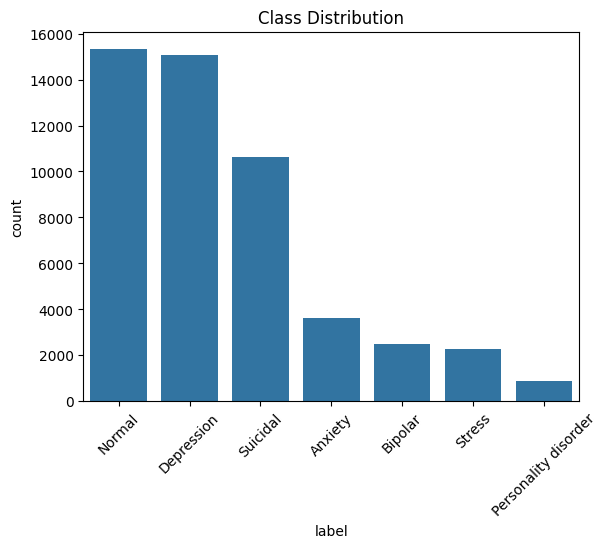

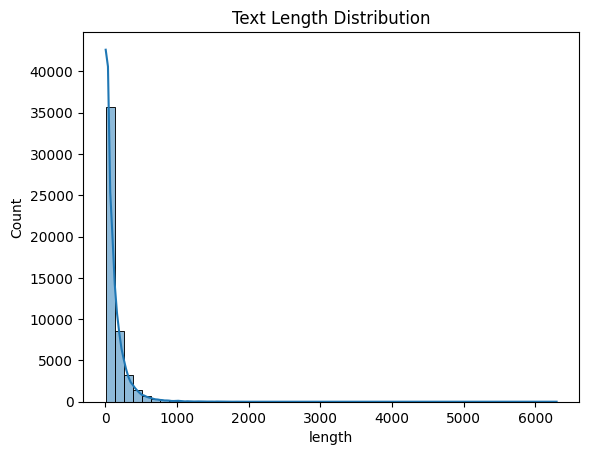

Map:   0%|          | 0/35217 [00:00<?, ? examples/s]

Map:   0%|          | 0/7547 [00:00<?, ? examples/s]

Map:   0%|          | 0/7547 [00:00<?, ? examples/s]

{'loss': 1.9391, 'grad_norm': 2.7233636379241943, 'learning_rate': 8.51305334846765e-07, 'epoch': 0.02271178741766977}
{'loss': 1.9413, 'grad_norm': 2.5568010807037354, 'learning_rate': 1.70261066969353e-06, 'epoch': 0.04542357483533954}
{'loss': 1.9225, 'grad_norm': 3.508279323577881, 'learning_rate': 2.553916004540295e-06, 'epoch': 0.06813536225300931}
{'loss': 1.9034, 'grad_norm': 2.768599271774292, 'learning_rate': 3.40522133938706e-06, 'epoch': 0.09084714967067908}
{'loss': 1.845, 'grad_norm': 3.2728662490844727, 'learning_rate': 4.256526674233825e-06, 'epoch': 0.11355893708834885}
{'loss': 1.7031, 'grad_norm': 8.471536636352539, 'learning_rate': 5.090805902383655e-06, 'epoch': 0.13627072450601863}
{'loss': 1.596, 'grad_norm': 7.990383625030518, 'learning_rate': 5.94211123723042e-06, 'epoch': 0.1589825119236884}
{'loss': 1.3842, 'grad_norm': 6.209765434265137, 'learning_rate': 6.7934165720771855e-06, 'epoch': 0.18169429934135817}
{'loss': 1.2733, 'grad_norm': 11.324405670166016, '

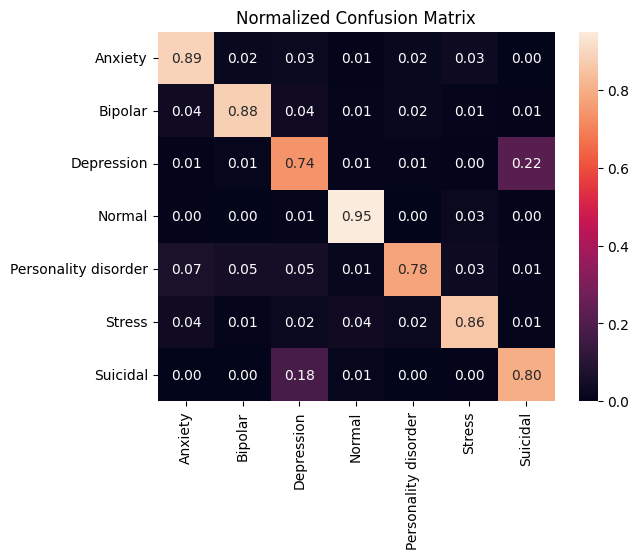

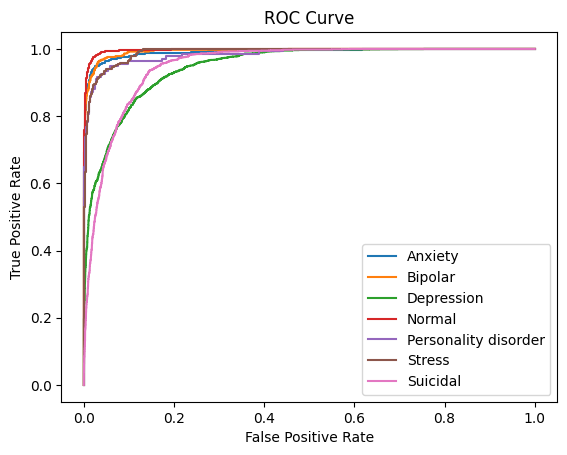

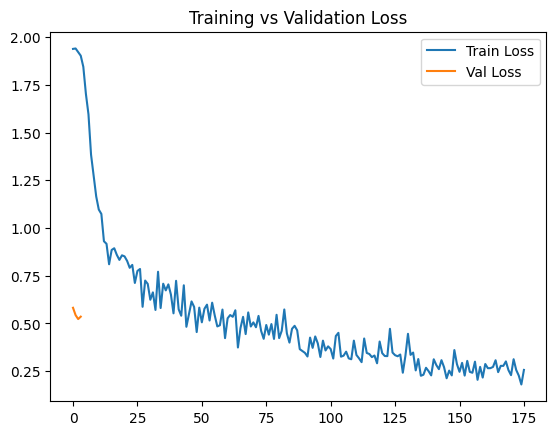

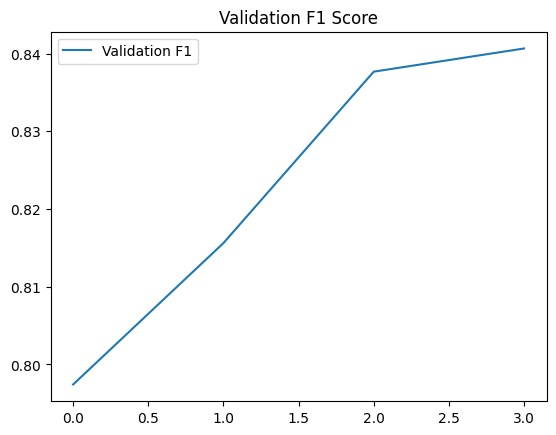

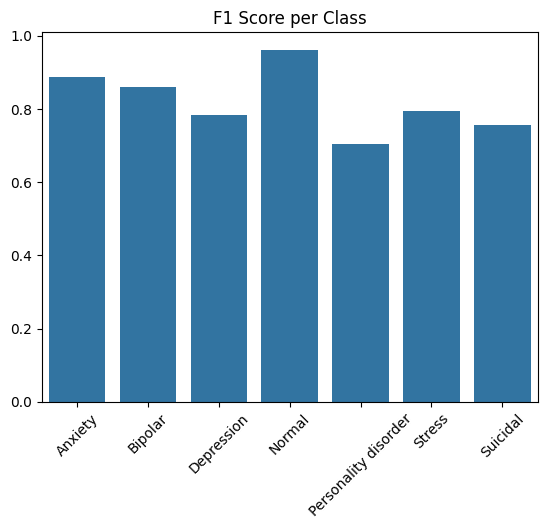

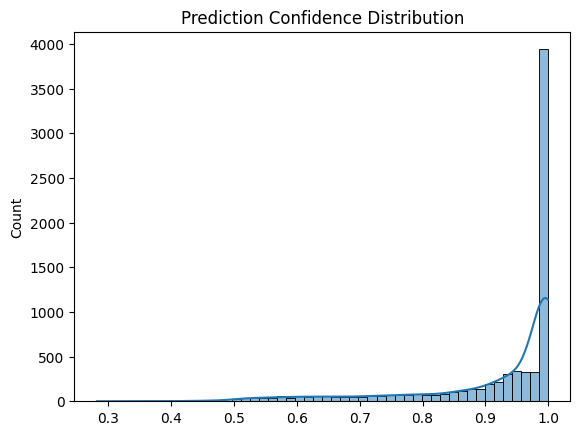

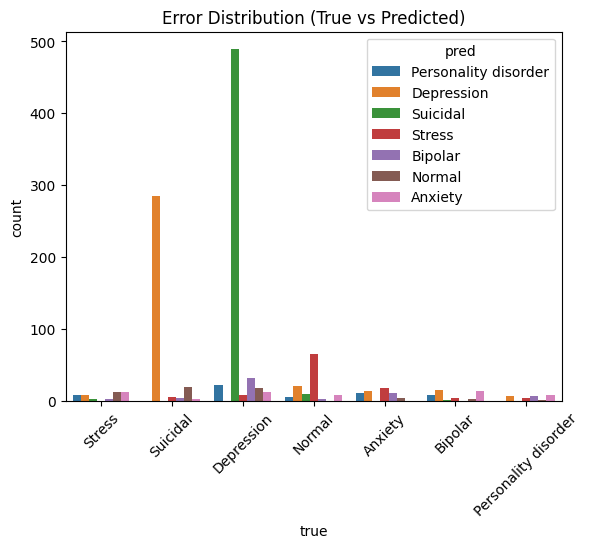

Everything is done and saved!


In [ ]:
# environmental setup
def setup_environment():
    # mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    # create working directory
    import os
    global SAVE_DIR
    SAVE_DIR = "/content/drive/MyDrive/mental health chatbot with sentiment analysis"
    os.makedirs(SAVE_DIR, exist_ok=True)

    # check GPU availability
    import torch
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("GPU not available, using CPU")

    print("CUDA Available:", torch.cuda.is_available())

# import libraries
def import_libraries():
    global pd, re, joblib, np, plt, sns, unicodedata
    global EarlyStoppingCallback, train_test_split, LabelEncoder, label_binarize
    global classification_report, accuracy_score, f1_score, precision_score, recall_score
    global roc_auc_score, confusion_matrix, roc_curve, compute_class_weight
    global Dataset, DebertaV2Tokenizer, DebertaV2ForSequenceClassification
    global Trainer, TrainingArguments, DataCollatorWithPadding
    global F, torch, random

    from transformers import logging
    logging.set_verbosity_error()

    import pandas as pd
    import re
    import joblib
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import unicodedata
    from transformers import EarlyStoppingCallback

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder, label_binarize
    from sklearn.metrics import (
        classification_report, accuracy_score,
        f1_score, precision_score, recall_score,
        roc_auc_score, confusion_matrix, roc_curve
    )
    from sklearn.utils.class_weight import compute_class_weight

    from datasets import Dataset
    from transformers import (
        DebertaV2Tokenizer,
        DebertaV2ForSequenceClassification,
        Trainer, TrainingArguments, DataCollatorWithPadding
    )

    import torch.nn.functional as F
    import torch
    import random

# set random seed
def set_seed_func(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# load dataaset
def load_dataset():
    global df
    # load dataset from Google Drive
    df = pd.read_csv(f"{SAVE_DIR}/dataset.csv")

    # show dataset
    print("Dataset Shape:", df.shape)
    print(df.head())

    # rename columns for consistency
    df.rename(columns={"statement": "text", "status": "label"}, inplace=True)

    # drop unnecessary index column
    df.drop(columns=["Unnamed: 0"], inplace=True)

# data cleaning
def clean_data():
    global df

    # check missing values
    print("Missing values:\n", df.isnull().sum())

    # drop rows with missing values
    df = df.dropna(subset=["text", "label"])

    # remove empty strings
    df = df[df["text"].str.strip() != ""]

    # remove short texts
    df = df[df["text"].apply(lambda x: len(str(x).split()) > 2)]

    # check duplicate data
    print("Duplicates:", df.duplicated(subset=["text"]).sum())
    # drop duplicate data
    df = df.drop_duplicates(subset=["text"])

    print("After cleaning:", df.shape)

# exploratory data analysis
def eda():

    # class distribution
    order = df["label"].value_counts().index

    sns.countplot(x=df["label"], order=order)
    plt.title("Class Distribution")
    plt.xticks(rotation=45)
    plt.savefig(f"{SAVE_DIR}/class_distribution.png")
    plt.show()

    # text length distribution
    df["length"] = df["text"].apply(lambda x: len(x.split()))
    sns.histplot(df["length"], bins=50, kde=True)
    plt.title("Text Length Distribution")
    plt.savefig(f"{SAVE_DIR}/text_length.png")
    plt.show()


# text preprocessing
def preprocess_text():
    global df

    def clean_text(text):

        #unicode normalization
        text = unicodedata.normalize("NFKC", str(text))

        # remove URLs
        text = re.sub(r"http\S+|www\S+", "", text)

        # normalize repeated characters
        text = re.sub(r"(.)\1{2,}", r"\1\1", text)

        # remove invisible characters
        text = re.sub(r"[\u200B-\u200D\uFEFF]", "", text)

        #normalize whitespace
        text = re.sub(r"\s+", " ", text)

        return text.strip()

    df["text"] = df["text"].apply(clean_text)
    df = df[df["text"].str.strip() != ""]

# label encoding
def encode_labels():
    global df, label_encoder, num_labels

    # convert categorical labels to numerical format
    label_encoder = LabelEncoder()
    df["label"] = label_encoder.fit_transform(df["label"])
    num_labels = len(label_encoder.classes_)

# split data (train(70%)/val(15%)/test(15%))
def split_data():
    global train_texts, val_texts, test_texts
    global train_labels, val_labels, test_labels

    # train/test + temp split
    train_texts, temp_texts, train_labels, temp_labels = train_test_split(
        df["text"], df["label"], test_size=0.3,
        stratify=df["label"], random_state=42
    )

    # validation/test split
    val_texts, test_texts, val_labels, test_labels = train_test_split(
        temp_texts, temp_labels, test_size=0.5,
        stratify=temp_labels, random_state=42
    )

    # reset indices
    train_texts = train_texts.reset_index(drop=True)
    val_texts = val_texts.reset_index(drop=True)
    test_texts = test_texts.reset_index(drop=True)

    train_labels = train_labels.reset_index(drop=True)
    val_labels = val_labels.reset_index(drop=True)
    test_labels = test_labels.reset_index(drop=True)

# dataset preparation + tokenization
def prepare_datasets():
    global train_dataset, val_dataset, test_dataset, tokenizer, data_collator

    # convert to HuggingFace Dataset
    train_dataset = Dataset.from_dict({"text": train_texts.tolist(), "labels": train_labels.tolist()})
    val_dataset = Dataset.from_dict({"text": val_texts.tolist(), "labels": val_labels.tolist()})
    test_dataset = Dataset.from_dict({"text": test_texts.tolist(), "labels": test_labels.tolist()})

    # load tokenizer
    tokenizer = DebertaV2Tokenizer.from_pretrained("microsoft/deberta-v3-base")

    # tokeization function
    def tokenize(example):
        return tokenizer(example["text"], truncation=True, max_length=256)

    # apply tokenization
    train_dataset = train_dataset.map(tokenize, batched=True, remove_columns=["text"])
    val_dataset = val_dataset.map(tokenize, batched=True, remove_columns=["text"])
    test_dataset = test_dataset.map(tokenize, batched=True, remove_columns=["text"])

    # padding for batching
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # set PyTorch format
    train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# model building
def build_model():
    global model, class_weights, trainer, training_args

    # compute class weights for imbalanced data
    class_weights_np = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_labels),
        y=train_labels
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

    # load pretrained model
    model = DebertaV2ForSequenceClassification.from_pretrained(
        "microsoft/deberta-v3-base",
        num_labels=num_labels
    )

    model.gradient_checkpointing_enable()
    model.to(device)

    # training configuration
    training_args = TrainingArguments(
        output_dir="./results",
        report_to="none",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=1.5e-5,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,
        num_train_epochs=4,
        fp16=True,
        max_grad_norm=1.0,
        load_best_model_at_end=True,
        metric_for_best_model="weighted_f1",
        greater_is_better=True,
        logging_steps=50
    )

    # custom trainer with weighted cross entropy loss
    class CustomTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False):
            labels = inputs.get("labels")
            outputs = model(**inputs)
            logits = outputs.get("logits")
            loss = F.cross_entropy(logits, labels, weight=class_weights)
            return (loss, outputs) if return_outputs else loss

    # metrics calculation
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {
            "weighted_f1": f1_score(labels, preds, average="weighted"),
            "macro_f1": f1_score(labels, preds, average="macro"),
            "accuracy": accuracy_score(labels, preds),
            "precision": precision_score(labels, preds, average="weighted"),
            "recall": recall_score(labels, preds, average="weighted"),
        }

    # initialize trainer
    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

# training
def train_model():
    torch.cuda.empty_cache()
    trainer.train()
    trainer.save_state()

# model evaluation
def evaluate_model():
    global y_pred, y_prob, class_names

    # generate predictions
    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_prob = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()

    # compute classification metricss
    print(classification_report(test_labels, y_pred, target_names=label_encoder.classes_))
    class_names = label_encoder.classes_

# error analysis
def error_analysis():
    global error_df

    # identify incorrect predictions
    errors = []

    # store confidence scores
    for i in range(len(y_pred)):
        if y_pred[i] != test_labels.iloc[i]:
            confidence = np.max(y_prob[i])

            errors.append({
                "text": test_texts.iloc[i],
                "true": class_names[test_labels.iloc[i]],
                "pred": class_names[y_pred[i]],
                "confidence": float(confidence)
            })

    error_df = pd.DataFrame(errors)

    # save results to csv
    error_df.to_csv(f"{SAVE_DIR}/errors.csv", index=False)

    print("Error analysis saved:", error_df.shape)

# data visualization of model performance
def evaluation_graphs():
    global y_pred, y_prob, class_names

    # confusion matrix
    cm = confusion_matrix(test_labels, y_pred)
    cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm, annot=True, fmt=".2f",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title("Normalized Confusion Matrix")
    plt.savefig(f"{SAVE_DIR}/confusion_matrix.png")
    plt.show()

    # ROC curve
    y_test_bin = label_binarize(np.array(test_labels), classes=list(range(num_labels)))

    for i in range(num_labels):
        if len(np.unique(y_test_bin[:, i])) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{class_names[i]}")

    plt.legend()
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.savefig(f"{SAVE_DIR}/roc_curve.png")
    plt.show()

    # training curves
    logs = trainer.state.log_history

    train_loss, eval_loss, eval_f1 = [], [], []

    for log in logs:
        if "loss" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
        if "eval_loss" in log:
            eval_loss.append(log["eval_loss"])
        if "eval_weighted_f1" in log:
            eval_f1.append(log["eval_weighted_f1"])

    plt.plot(train_loss, label="Train Loss")
    plt.plot(eval_loss, label="Val Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.savefig(f"{SAVE_DIR}/loss_curve.png")
    plt.show()

    plt.plot(eval_f1, label="Validation F1")
    plt.title("Validation F1 Score")
    plt.legend()
    plt.savefig(f"{SAVE_DIR}/f1_curve.png")
    plt.show()

    # F1 per class
    report = classification_report(
        test_labels, y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )

    f1_scores = []
    for label in label_encoder.classes_:
        if label in report:
            f1_scores.append(report[label]["f1-score"])
        else:
            f1_scores.append(0)

    sns.barplot(x=label_encoder.classes_, y=f1_scores)
    plt.title("F1 Score per Class")
    plt.xticks(rotation=45)
    plt.savefig(f"{SAVE_DIR}/f1_per_class.png")
    plt.show()

    # confidence distribution
    confidence = np.max(y_prob, axis=1)

    sns.histplot(confidence, bins=50, kde=True)
    plt.title("Prediction Confidence Distribution")
    plt.savefig(f"{SAVE_DIR}/confidence.png")
    plt.show()

# visualise error distribution
def error_visualization():
    sns.countplot(x="true", hue="pred", data=error_df)
    plt.title("Error Distribution (True vs Predicted)")
    plt.xticks(rotation=45)
    plt.savefig(f"{SAVE_DIR}/error_distribution.png")
    plt.show()

# save models & outputs
def save_outputs():

    # save tokenizer
    tokenizer.save_pretrained(f"{SAVE_DIR}/model")

    # save label encoder
    joblib.dump(label_encoder, f"{SAVE_DIR}/label_encoder.pkl")

    # save model
    trainer.save_model(f"{SAVE_DIR}/model")

    # save label lists
    with open(f"{SAVE_DIR}/labels.txt", "w") as f:
        for label in label_encoder.classes_:
            f.write(label + "\n")

    print("Everything is done and saved!")


# main function
def main():
    setup_environment()
    import_libraries()
    set_seed_func()

    load_dataset()
    clean_data()
    eda()
    preprocess_text()
    encode_labels()
    split_data()
    prepare_datasets()
    build_model()
    train_model()
    evaluate_model()
    error_analysis()
    evaluation_graphs()
    error_visualization()
    save_outputs()


# run everything
main()